# Object detection, an introduction

### The model is the small part. The evaluation machinery is what transfers

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Intersection over union, non-maximum suppression and average precision written from scratch; how a single-shot detector turns a grid of anchors into boxes; why detection is scored with AP rather than accuracy; and how AP moves when you change the matching threshold and the suppression threshold |
| **You should already know** | [08-02 A convolutional network, layer by layer](../02-a-cnn-layer-by-layer/) and [08-06 Segmentation](../06-image-segmentation/) for the IoU definition |
| **Dataset** | Synthetic 64x64 images generated in this notebook, so every ground truth box is exact |
| **Runtime** | Two to four minutes on a laptop CPU. The device it used is printed below |
| **Next** | [09-01 Text preprocessing](../../09-sequences-and-language/01-text-preprocessing/) |

---

## 1. What this chapter is and is not

The detector below is deliberately small and it will not impress anybody. That
is the plan. A modern detector is a large backbone plus a pile of engineering,
and reproducing one on a laptop teaches you about the pile rather than about
detection.

What does transfer, unchanged, from this notebook to any detector you will ever
use is the machinery around the model:

- **Intersection over union**, which decides whether a predicted box counts as
  finding a true one.
- **Non-maximum suppression**, because a detector that scores every position
  will fire several times on the same object and something has to clean that up.
- **Average precision**, because accuracy is meaningless when the answer is a
  variable-length list of boxes with confidences attached.

All three are written out here in a few lines each. The rest of the chapter
measures how AP responds to the two thresholds you are forced to choose, which
is the part most people meet only when a number they did not expect appears in a
comparison table.

### The idea, before any of that

Classification asks what is in the image. Detection asks what is in it **and
where**, for an unknown number of things. The output length is not fixed, which
breaks every loss function in the previous chapters.

The single-shot answer is to make the output fixed-length after all. Cut the
image into a grid of cells. Give each cell a small set of reference boxes,
called **anchors**, of chosen sizes. Now the model has a fixed number of slots,
and for each slot it answers two questions: is there an object here, and how do I
have to nudge this anchor to fit it. Everything after that is bookkeeping.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"

SIDE = 64
GRID = 8                    # cells per side
STRIDE = SIDE // GRID       # pixels per cell
ANCHORS = [(10.0, 10.0), (17.0, 17.0)]
N_TRAIN, N_TEST = 600, 150
BATCH = 16
EPOCHS = 25
LR = 2e-3
SCORE_FLOOR = 0.05          # keep low, so there is something for suppression to do

NOTEBOOK_STARTED = time.perf_counter()
print(f"torch {torch.__version__} on {device}")
print(f"{GRID}x{GRID} cells of {STRIDE} pixels, {len(ANCHORS)} anchors per cell, "
      f"{GRID * GRID * len(ANCHORS)} slots per image")

torch 2.11.0+cu128 on cuda
8x8 cells of 8 pixels, 2 anchors per cell, 128 slots per image


## 2. The data, with exact boxes

Bright discs on a noisy background, one to four per image, radii drawn from a
range that both anchor sizes have to cover. The ground truth box of a disc is
its tight bounding square, which I know exactly because I drew the disc.

Discs are allowed to overlap. That is on purpose: overlapping objects are where
non-maximum suppression stops being free and starts throwing away correct
detections, which section 5 measures. Allowed is not the same as common, and
section 5 also measures how much these objects actually overlap, which turns out
to decide the shape of the whole sweep.

In [2]:
def make_example(rng, side=SIDE):
    """One image and its list of (x1, y1, x2, y2) boxes."""
    rows, cols = np.mgrid[0:side, 0:side]
    image = 0.12 + 0.04 * rng.standard_normal((side, side))
    boxes = []
    for _ in range(rng.integers(1, 5)):
        radius = float(rng.integers(4, 10))
        cy, cx = rng.integers(int(radius) + 2, side - int(radius) - 2, size=2)
        inside = (rows - cy) ** 2 + (cols - cx) ** 2 <= radius ** 2
        image = np.where(inside, 0.60 + 0.30 * rng.random(), image)
        boxes.append([cx - radius, cy - radius, cx + radius, cy + radius])
    image = image + 0.05 * rng.standard_normal((side, side))
    return np.clip(image, 0.0, 1.0).astype(np.float32), np.array(boxes, dtype=np.float32)


def make_set(n, seed):
    rng = np.random.default_rng(seed)
    pairs = [make_example(rng) for _ in range(n)]
    images = torch.from_numpy(np.stack([p[0] for p in pairs])).unsqueeze(1)
    return images, [p[1] for p in pairs]


x_train, boxes_train = make_set(N_TRAIN, SEED)
x_test, boxes_test = make_set(N_TEST, SEED + 1)

train_counts = np.array([len(b) for b in boxes_train])
test_sizes = np.concatenate([b[:, 2] - b[:, 0] for b in boxes_test])
print(f"train: {len(x_train)} images, {train_counts.sum()} objects, "
      f"{train_counts.mean():.2f} per image")
print(f"test : {len(x_test)} images, {sum(len(b) for b in boxes_test)} objects")
print(f"object side lengths in the test set: {test_sizes.min():.0f} to "
      f"{test_sizes.max():.0f} pixels, anchors are {[a[0] for a in ANCHORS]}")

train: 600 images, 1526 objects, 2.54 per image
test : 150 images, 372 objects
object side lengths in the test set: 8 to 18 pixels, anchors are [10.0, 17.0]


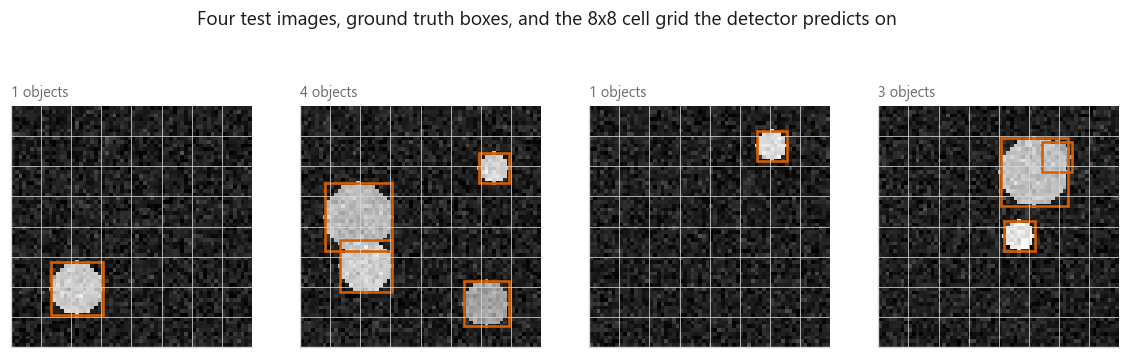

In [3]:
def draw_boxes(ax, boxes, colour, linestyle="-", label=None):
    """Outline boxes given as (x1, y1, x2, y2) in pixel coordinates."""
    for i, (x1, y1, x2, y2) in enumerate(np.asarray(boxes).reshape(-1, 4)):
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False,
                               edgecolor=colour, linewidth=1.7, linestyle=linestyle,
                               label=label if i == 0 else None))


fig, axes = plt.subplots(1, 4, figsize=(13.0, 3.6))
for ax, index in zip(axes, range(4)):
    ax.imshow(x_test[index, 0], cmap="gray", vmin=0, vmax=1)
    draw_boxes(ax, boxes_test[index], style.HIGHLIGHT, "-")
    for x in range(STRIDE, SIDE, STRIDE):
        ax.axvline(x - 0.5, color=style.RULE, lw=0.5)
        ax.axhline(x - 0.5, color=style.RULE, lw=0.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{len(boxes_test[index])} objects", fontsize=9.5,
                 color=style.MUTED, loc="left")

fig.suptitle(f"Four test images, ground truth boxes, and the {GRID}x{GRID} cell grid "
             f"the detector predicts on",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-data-and-grid.png")

## 3. From scratch: the three pieces that transfer

### Intersection over union, on boxes

The same quantity as in [08-06](../06-image-segmentation/), computed with
arithmetic instead of pixel counting. The overlap of two axis-aligned boxes is
itself a box, so the intersection width is
$\max(0,\ \min(x_2, x_2') - \max(x_1, x_1'))$ and likewise for height. The
$\max(0, \cdot)$ is what handles boxes that do not touch.

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A| + |B| - |A \cap B|}$$

In [4]:
def box_iou(a, b):
    """IoU between every box in `a` (N, 4) and every box in `b` (M, 4). Returns (N, M)."""
    a = np.asarray(a, dtype=np.float64).reshape(-1, 4)
    b = np.asarray(b, dtype=np.float64).reshape(-1, 4)
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))

    left = np.maximum(a[:, None, 0], b[None, :, 0])
    top = np.maximum(a[:, None, 1], b[None, :, 1])
    right = np.minimum(a[:, None, 2], b[None, :, 2])
    bottom = np.minimum(a[:, None, 3], b[None, :, 3])

    overlap = np.clip(right - left, 0, None) * np.clip(bottom - top, 0, None)
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    union = area_a[:, None] + area_b[None, :] - overlap
    return np.where(union > 0, overlap / np.maximum(union, 1e-12), 0.0)


checks = pd.DataFrame([
    {"case": "identical", "a": [0, 0, 10, 10], "b": [0, 0, 10, 10], "by hand": 1.0},
    {"case": "no overlap", "a": [0, 0, 10, 10], "b": [20, 20, 30, 30], "by hand": 0.0},
    {"case": "half overlap along x", "a": [0, 0, 10, 10], "b": [5, 0, 15, 10],
     "by hand": 50 / 150},
    {"case": "one inside the other", "a": [0, 0, 10, 10], "b": [2, 2, 8, 8],
     "by hand": 36 / 100},
    {"case": "touching edges only", "a": [0, 0, 10, 10], "b": [10, 0, 20, 10],
     "by hand": 0.0},
])
checks["box_iou"] = [float(box_iou([row["a"]], [row["b"]])[0, 0]) for _, row in checks.iterrows()]
checks["difference"] = checks["box_iou"] - checks["by hand"]
print(checks[["case", "by hand", "box_iou", "difference"]]
      .to_string(index=False, float_format="{:.6f}".format))

                case  by hand  box_iou  difference
           identical 1.000000 1.000000    0.000000
          no overlap 0.000000 0.000000    0.000000
half overlap along x 0.333333 0.333333    0.000000
one inside the other 0.360000 0.360000    0.000000
 touching edges only 0.000000 0.000000    0.000000


### Non-maximum suppression

A detector that scores every slot will produce several boxes on the same object,
because the slots next to the best one also see most of it. Non-maximum
suppression is the greedy fix: take the highest-scoring box, delete every
remaining box that overlaps it more than a threshold, repeat.

It is not a clever algorithm and it has a real cost. Two genuinely different
objects that overlap more than the threshold cannot both survive it, and section
5 measures what that costs as the threshold moves.

In [5]:
def nms(boxes, scores, threshold):
    """Greedy non-maximum suppression. Returns the indices kept, best score first."""
    order = np.argsort(scores)[::-1]
    keep = []
    while len(order) > 0:
        best = order[0]
        keep.append(int(best))
        if len(order) == 1:
            break
        overlaps = box_iou(boxes[best][None, :], boxes[order[1:]])[0]
        order = order[1:][overlaps <= threshold]
    return keep


demo_boxes = np.array([[10, 10, 30, 30], [12, 12, 32, 32], [11, 9, 29, 31],
                       [40, 40, 60, 60]], dtype=np.float32)
demo_scores = np.array([0.90, 0.85, 0.60, 0.75])

print("four boxes: three piled on one object, one on its own")
print("pairwise IoU:")
print(np.round(box_iou(demo_boxes, demo_boxes), 3))
for threshold in [0.3, 0.5, 0.9]:
    kept = nms(demo_boxes, demo_scores, threshold)
    print(f"threshold {threshold:.1f}: kept {len(kept)} of {len(demo_boxes)}, "
          f"scores {[float(demo_scores[i]) for i in kept]}")

four boxes: three piled on one object, one on its own
pairwise IoU:
[[1.    0.681 0.826 0.   ]
 [0.681 1.    0.683 0.   ]
 [0.826 0.683 1.    0.   ]
 [0.    0.    0.    1.   ]]
threshold 0.3: kept 2 of 4, scores [0.9, 0.75]
threshold 0.5: kept 2 of 4, scores [0.9, 0.75]
threshold 0.9: kept 4 of 4, scores [0.9, 0.85, 0.75, 0.6]


### Precision, recall and average precision

Now the scoring. A detector returns a list of boxes with confidences, so there
is no fixed set of predictions to compare against a fixed set of labels. The
standard protocol:

1. Pool every detection across every image and sort by confidence, highest first.
2. Walk down the list. A detection is a **true positive** if it overlaps an
   unmatched ground truth box in its own image by at least the IoU threshold, and
   a **false positive** otherwise. Each ground truth box can be claimed once, so
   the second box on the same object is a false positive however good it looks.
3. After each detection, record precision $TP/(TP+FP)$ and recall
   $TP/(\text{all ground truth})$.

That traces a curve. **Average precision** is the area under it, with the
precision first made monotone by replacing each value with the best precision at
any equal or higher recall. The interpolation matters and papers differ on it;
this is the all-point version used by VOC after 2010 and by COCO.

$$\text{AP} = \sum_{k} \big(r_k - r_{k-1}\big)\, \max_{\tilde r \ge r_k} p(\tilde r)$$

In [6]:
def precision_recall(detections, truths, iou_threshold):
    """Walk detections in confidence order and return (precision, recall, n_true).

    `detections` is a list per image of (boxes, scores); `truths` is a list per
    image of ground truth boxes.
    """
    pooled = []
    for image_id, (boxes, scores) in enumerate(detections):
        for box, score in zip(np.asarray(boxes).reshape(-1, 4), np.asarray(scores).ravel()):
            pooled.append((float(score), image_id, box))
    pooled.sort(key=lambda item: -item[0])

    n_true = sum(len(t) for t in truths)
    claimed = {i: np.zeros(len(t), dtype=bool) for i, t in enumerate(truths)}

    tp = np.zeros(len(pooled))
    fp = np.zeros(len(pooled))
    for rank, (_, image_id, box) in enumerate(pooled):
        available = truths[image_id]
        if len(available) == 0:
            fp[rank] = 1
            continue
        overlaps = box_iou(box[None, :], available)[0]
        overlaps[claimed[image_id]] = -1.0        # a matched box cannot be matched twice
        best = int(np.argmax(overlaps))
        if overlaps[best] >= iou_threshold:
            tp[rank] = 1
            claimed[image_id][best] = True
        else:
            fp[rank] = 1

    cumulative_tp, cumulative_fp = np.cumsum(tp), np.cumsum(fp)
    precision = cumulative_tp / np.maximum(cumulative_tp + cumulative_fp, 1e-12)
    recall = cumulative_tp / max(n_true, 1)
    return precision, recall, n_true


def average_precision(precision, recall):
    """Area under the precision-recall curve, all-point interpolated."""
    if len(precision) == 0:
        return 0.0
    padded_recall = np.concatenate([[0.0], recall, [1.0]])
    padded_precision = np.concatenate([[0.0], precision, [0.0]])
    for i in range(len(padded_precision) - 2, -1, -1):
        padded_precision[i] = max(padded_precision[i], padded_precision[i + 1])
    steps = np.where(padded_recall[1:] != padded_recall[:-1])[0]
    return float(np.sum((padded_recall[steps + 1] - padded_recall[steps])
                        * padded_precision[steps + 1]))


# A case small enough to do on paper: two true objects, three detections ranked
# true, false, true.
hand_truths = [np.array([[0, 0, 10, 10]], dtype=np.float32),
               np.array([[0, 0, 10, 10]], dtype=np.float32)]
hand_detections = [(np.array([[0, 0, 10, 10], [50, 50, 60, 60]], dtype=np.float32),
                    np.array([0.9, 0.7])),
                   (np.array([[0, 0, 10, 10]], dtype=np.float32), np.array([0.5]))]

p, r, n = precision_recall(hand_detections, hand_truths, 0.5)
by_hand = 0.5 * 1.0 + 0.5 * (2 / 3)
print(f"ranked outcomes: true, false, true, against {n} ground truth boxes")
print(f"precision: {np.round(p, 4)}")
print(f"recall   : {np.round(r, 4)}")
print(f"AP from the function : {average_precision(p, r):.6f}")
print(f"AP worked out by hand: {by_hand:.6f}")
print(f"difference           : {average_precision(p, r) - by_hand:.2e}")

ranked outcomes: true, false, true, against 2 ground truth boxes
precision: [1.     0.5    0.6667]
recall   : [0.5 0.5 1. ]
AP from the function : 0.833333
AP worked out by hand: 0.833333
difference           : 0.00e+00


### Why not accuracy

It is worth being concrete about why the machinery above exists rather than a
single fraction-correct number.

Accuracy needs a fixed set of items to be right or wrong about. Detection has
no such set. The model proposes a variable number of boxes, and each one can be
right in position but wrong in size, or right about an object another box has
already claimed, or right but with a confidence so low you would never have
shown it.

You can force an accuracy out of the grid by asking, for each of the fixed slots,
whether the model's objectness call was correct. That number is computed below,
next to AP for the same model, and the gap between them is the argument.

## 4. In practice: a single-shot detector

The encoder side is an ordinary convolutional stack that takes 64x64 down to the
8x8 grid. The head is one 1x1 convolution producing five numbers per anchor: an
objectness logit and four box parameters.

The parameterisation is the part worth reading twice. Predicting box corners in
pixels directly makes the network learn the coordinate system. Instead each slot
predicts a small correction to a known anchor:

- centre: `cx = (column + sigmoid(tx)) * stride`, so the sigmoid keeps the centre
  inside the cell that is responsible for it
- size: `w = anchor_w * exp(tw)`, so a prediction of zero means "the anchor was
  already the right size" and the network starts from a sensible guess

In [7]:
class Detector(nn.Module):
    """Convolutional stack down to the grid, then one logit and four numbers per anchor."""

    def __init__(self, n_anchors=len(ANCHORS), width=16):
        super().__init__()
        self.n_anchors = n_anchors

        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.MaxPool2d(2),
            )

        self.backbone = nn.Sequential(
            block(1, width),            # 64 -> 32
            block(width, 2 * width),    # 32 -> 16
            block(2 * width, 4 * width),  # 16 -> 8
        )
        self.head = nn.Conv2d(4 * width, n_anchors * 5, 1)

    def forward(self, x):
        out = self.head(self.backbone(x))                       # (B, A*5, G, G)
        b, _, grid_h, grid_w = out.shape
        return out.view(b, self.n_anchors, 5, grid_h, grid_w).permute(0, 1, 3, 4, 2)


def encode_targets(box_lists):
    """Turn per-image box lists into the fixed-size targets the loss needs."""
    n = len(box_lists)
    objectness = torch.zeros(n, len(ANCHORS), GRID, GRID)
    parameters = torch.zeros(n, len(ANCHORS), GRID, GRID, 4)
    positives = torch.zeros(n, len(ANCHORS), GRID, GRID, dtype=torch.bool)
    collisions = 0

    for i, boxes in enumerate(box_lists):
        for x1, y1, x2, y2 in boxes:
            cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
            w, h = x2 - x1, y2 - y1
            col = min(int(cx // STRIDE), GRID - 1)
            row = min(int(cy // STRIDE), GRID - 1)
            # the anchor whose size is closest in log space
            fit = [abs(np.log(w / aw)) + abs(np.log(h / ah)) for aw, ah in ANCHORS]
            a = int(np.argmin(fit))
            if positives[i, a, row, col]:
                collisions += 1        # one slot, two objects: the grid cannot hold both
            objectness[i, a, row, col] = 1.0
            positives[i, a, row, col] = True
            parameters[i, a, row, col] = torch.tensor([
                cx / STRIDE - col, cy / STRIDE - row,
                float(np.log(w / ANCHORS[a][0])), float(np.log(h / ANCHORS[a][1])),
            ])
    return objectness, parameters, positives, collisions


obj_train, par_train, pos_train, lost = encode_targets(boxes_train)
print(f"{int(pos_train.sum())} slots hold an object out of "
      f"{pos_train.numel()} in the training set "
      f"({float(pos_train.float().mean()):.4f} of them)")
print(f"{lost} objects were dropped because another object already owned their "
      f"cell and anchor")
print("That is a real limit of a single-shot grid, not a bug: two objects whose "
      "centres share a cell and whose sizes prefer the same anchor cannot both be "
      "assigned.")

1500 slots hold an object out of 76800 in the training set (0.0195 of them)
26 objects were dropped because another object already owned their cell and anchor
That is a real limit of a single-shot grid, not a bug: two objects whose centres share a cell and whose sizes prefer the same anchor cannot both be assigned.


The imbalance in the first printed line is why the objectness loss needs a
weight. Almost every slot is background, so unweighted binary cross entropy is
minimised well enough by never firing. `pos_weight` multiplies the positive term
and is the smallest fix that works.

In [8]:
POS_WEIGHT = 20.0
BOX_WEIGHT = 5.0


def detection_loss(prediction, objectness, parameters, positives):
    """Weighted objectness plus a box term that only applies where an object is."""
    obj_loss = F.binary_cross_entropy_with_logits(
        prediction[..., 0], objectness,
        pos_weight=torch.tensor(POS_WEIGHT, device=prediction.device))

    if positives.any():
        # sigmoid on the two centre offsets, raw on the two log-size corrections
        predicted = torch.cat([torch.sigmoid(prediction[..., 1:3]), prediction[..., 3:5]],
                              dim=-1)
        box_loss = F.smooth_l1_loss(predicted[positives], parameters[positives])
    else:
        box_loss = torch.zeros((), device=prediction.device)
    return obj_loss + BOX_WEIGHT * box_loss, float(obj_loss), float(box_loss)


rows_grid, cols_grid = torch.meshgrid(torch.arange(GRID), torch.arange(GRID), indexing="ij")
ANCHOR_WH = torch.tensor(ANCHORS)


def decode(prediction):
    """Turn a network output into boxes and scores, per image, before suppression."""
    scores = torch.sigmoid(prediction[..., 0])                       # (B, A, G, G)
    offset_x = torch.sigmoid(prediction[..., 1]) + cols_grid.to(prediction.device)
    offset_y = torch.sigmoid(prediction[..., 2]) + rows_grid.to(prediction.device)
    centre_x, centre_y = offset_x * STRIDE, offset_y * STRIDE

    widths = ANCHOR_WH[:, 0].to(prediction.device).view(1, -1, 1, 1) * torch.exp(prediction[..., 3])
    heights = ANCHOR_WH[:, 1].to(prediction.device).view(1, -1, 1, 1) * torch.exp(prediction[..., 4])

    boxes = torch.stack([centre_x - widths / 2, centre_y - heights / 2,
                         centre_x + widths / 2, centre_y + heights / 2], dim=-1)
    return boxes.reshape(len(prediction), -1, 4), scores.reshape(len(prediction), -1)

Encoding and decoding have to be inverses of each other, and a sign error in
either is invisible in the loss curve and fatal in the output. So before
training anything: take the true boxes of one test image, encode them, build the
prediction a perfect network would have produced, decode it, and compare.

In [9]:
def logit(p):
    p = p.clamp(1e-6, 1 - 1e-6)
    return torch.log(p / (1 - p))


check_boxes = [boxes_test[0]]
check_obj, check_par, check_pos, _ = encode_targets(check_boxes)

perfect = torch.zeros(1, len(ANCHORS), GRID, GRID, 5)
perfect[..., 0] = -10.0                       # everything is background
perfect[check_pos, 0] = 10.0                  # except the slots that own an object
perfect[..., 1:3] = logit(check_par[..., :2])  # undo the sigmoid the decoder applies
perfect[..., 3:5] = check_par[..., 2:]

decoded_boxes, decoded_scores = decode(perfect)
recovered = decoded_boxes[0][decoded_scores[0] > 0.5].numpy()
original = np.asarray(check_boxes[0])

print(f"{len(original)} true boxes in, {len(recovered)} decoded back out")
if len(recovered) == len(original):
    error = np.abs(np.sort(recovered, axis=0) - np.sort(original, axis=0)).max()
    print(f"largest coordinate error over the round trip: {error:.2e} pixels")
else:
    print("the counts differ, which means two objects wanted the same cell and "
          "anchor and the grid could only keep one")

1 true boxes in, 1 decoded back out
largest coordinate error over the round trip: 7.63e-06 pixels


In [10]:
def train_detector(epochs=EPOCHS, seed=SEED):
    torch.manual_seed(seed)
    model = Detector().to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(TensorDataset(x_train, obj_train, par_train, pos_train),
                        batch_size=BATCH, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))

    history, started = [], time.perf_counter()
    for epoch in range(1, epochs + 1):
        totals = np.zeros(2)
        for xb, ob, pb, mb in loader:
            xb, ob, pb, mb = xb.to(device), ob.to(device), pb.to(device), mb.to(device)
            optimiser.zero_grad(set_to_none=True)
            loss, obj_part, box_part = detection_loss(model(xb), ob, pb, mb)
            loss.backward()
            optimiser.step()
            totals += np.array([obj_part, box_part])
        history.append({"epoch": epoch, "objectness loss": totals[0] / len(loader),
                        "box loss": totals[1] / len(loader)})
    return model, pd.DataFrame(history), time.perf_counter() - started


detector, history, seconds = train_detector()
print(f"trained in {seconds:.0f} s on {device}")
print(history.iloc[[0, len(history) // 2, -1]].to_string(index=False,
                                                         float_format="{:.4f}".format))

C:\Users\pilot\AppData\Local\Temp\ipykernel_33564\2720605135.py:18: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return obj_loss + BOX_WEIGHT * box_loss, float(obj_loss), float(box_loss)


trained in 7 s on cuda
 epoch  objectness loss  box loss
     1           0.7116    0.0651
    13           0.0164    0.0031
    25           0.0020    0.0011


In [11]:
@torch.no_grad()
def raw_detections(model, images, floor=SCORE_FLOOR, batch=32):
    """Every slot above the score floor, per image, with no suppression applied."""
    model.eval()
    out = []
    for start in range(0, len(images), batch):
        boxes, scores = decode(model(images[start:start + batch].to(device)))
        boxes, scores = boxes.cpu().numpy(), scores.cpu().numpy()
        for i in range(len(boxes)):
            keep = scores[i] >= floor
            out.append((boxes[i][keep], scores[i][keep]))
    model.train()
    return out


def suppress(detections, threshold):
    """Apply non-maximum suppression image by image."""
    output = []
    for boxes, scores in detections:
        if len(boxes) == 0:
            output.append((boxes, scores))
            continue
        keep = nms(boxes, scores, threshold)
        output.append((boxes[keep], scores[keep]))
    return output


raw = raw_detections(detector, x_test)
suppressed = suppress(raw, 0.5)

per_image_raw = np.mean([len(b) for b, _ in raw])
per_image_kept = np.mean([len(b) for b, _ in suppressed])
print(f"above the score floor of {SCORE_FLOOR}: {per_image_raw:.1f} boxes per image")
print(f"after suppression at 0.5           : {per_image_kept:.1f} boxes per image")
print(f"true objects per image             : "
      f"{np.mean([len(b) for b in boxes_test]):.1f}")

above the score floor of 0.05: 3.2 boxes per image
after suppression at 0.5           : 2.9 boxes per image
true objects per image             : 2.5


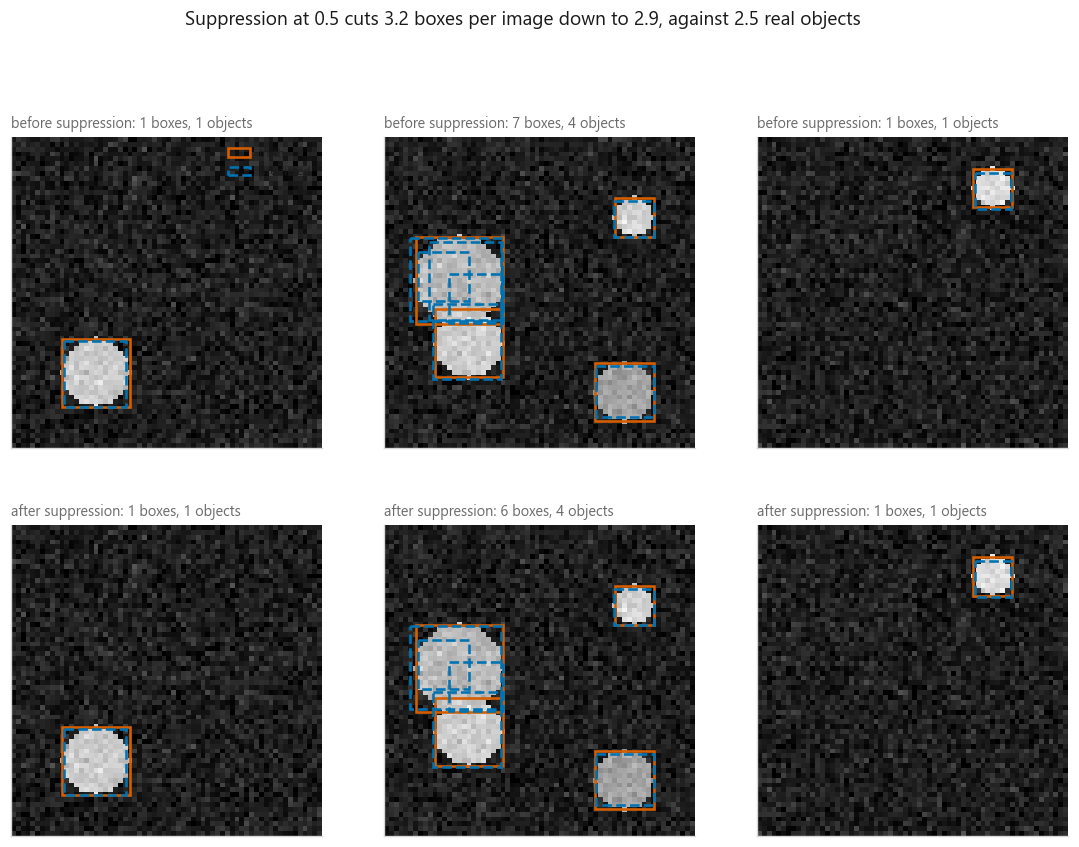

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12.4, 8.4))
for column, index in enumerate([0, 1, 2]):
    for row, (label, detections) in enumerate([("before suppression", raw),
                                               ("after suppression", suppressed)]):
        ax = axes[row, column]
        ax.imshow(x_test[index, 0], cmap="gray", vmin=0, vmax=1)
        draw_boxes(ax, boxes_test[index], style.HIGHLIGHT, "-", label="truth")
        boxes, scores = detections[index]
        draw_boxes(ax, boxes, style.PALETTE[0], "--", label="predicted")
        ax.set_xlim(-0.5, SIDE - 0.5); ax.set_ylim(SIDE - 0.5, -0.5)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(f"{label}: {len(boxes)} boxes, {len(boxes_test[index])} objects",
                     fontsize=9.5, color=style.MUTED, loc="left")
        if row == 0 and column == 0:
            ax.legend(loc="upper right", fontsize=8)

fig.suptitle(f"Suppression at 0.5 cuts {per_image_raw:.1f} boxes per image down to "
             f"{per_image_kept:.1f}, against {np.mean([len(b) for b in boxes_test]):.1f} "
             f"real objects",
             x=0.5, y=1.01, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-02-suppression.png")

## 5. What the two thresholds do to the score

The detector now exists and stops being the subject. Two numbers were chosen by
hand above, and every reported AP depends on both:

- the **matching threshold**, how much overlap counts as finding the object
- the **suppression threshold**, how much overlap between two predictions counts
  as a duplicate

### AP against the matching threshold

In [13]:
IOU_THRESHOLDS = np.round(np.arange(0.30, 0.86, 0.05), 2)

curves, rows = {}, []
for threshold in IOU_THRESHOLDS:
    p, r, n_true = precision_recall(suppressed, boxes_test, float(threshold))
    curves[float(threshold)] = (p, r)
    rows.append({"IoU threshold": float(threshold),
                 "AP": average_precision(p, r),
                 "best recall reached": float(r.max()) if len(r) else 0.0,
                 "precision at that recall": float(p[-1]) if len(p) else 0.0})

by_iou = pd.DataFrame(rows)
print(by_iou.to_string(index=False, float_format="{:.4f}".format))

ap50 = float(by_iou.loc[np.isclose(by_iou["IoU threshold"], 0.50), "AP"].iloc[0])
ap_mean = float(by_iou[by_iou["IoU threshold"] >= 0.499]["AP"].mean())
print(f"\nAP at 0.50 (what most papers call AP50): {ap50:.4f}")
print(f"averaged over thresholds from 0.50 up (the COCO style): {ap_mean:.4f}")
print(f"AP fell from {by_iou['AP'].iloc[0]:.4f} at IoU "
      f"{by_iou['IoU threshold'].iloc[0]:.2f} to {by_iou['AP'].iloc[-1]:.4f} at "
      f"{by_iou['IoU threshold'].iloc[-1]:.2f}")

 IoU threshold     AP  best recall reached  precision at that recall
        0.3000 0.9604               0.9624                    0.8192
        0.3500 0.9604               0.9624                    0.8192
        0.4000 0.9581               0.9597                    0.8169
        0.4500 0.9579               0.9597                    0.8169
        0.5000 0.9469               0.9489                    0.8078
        0.5500 0.9467               0.9489                    0.8078
        0.6000 0.9139               0.9220                    0.7849
        0.6500 0.8932               0.9032                    0.7689
        0.7000 0.8445               0.8629                    0.7346
        0.7500 0.7623               0.8065                    0.6865
        0.8000 0.6000               0.7070                    0.6018
        0.8500 0.3423               0.5161                    0.4394

AP at 0.50 (what most papers call AP50): 0.9469
averaged over thresholds from 0.50 up (the COCO style)

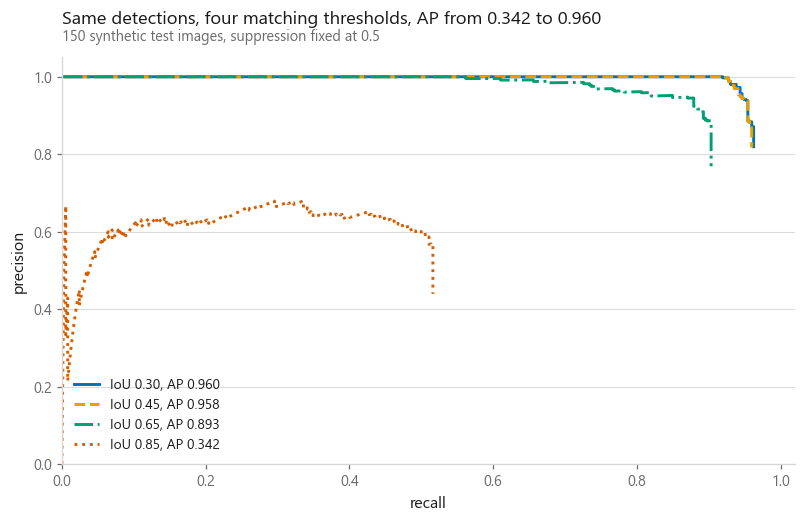

In [14]:
last = len(IOU_THRESHOLDS) - 1
shown = [float(IOU_THRESHOLDS[i]) for i in [0, last // 3, 2 * last // 3, last]]
shown_ap = [average_precision(*curves[t]) for t in shown]

fig, ax = plt.subplots(figsize=(8.6, 4.8))
for i, (threshold, value) in enumerate(zip(shown, shown_ap)):
    p, r = curves[threshold]
    ax.plot(r, p, color=style.PALETTE[i], ls=style.DASHES[i],
            label=f"IoU {threshold:.2f}, AP {value:.3f}")

ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", fontsize=9)
style.title(
    ax,
    f"Same detections, four matching thresholds, AP from {min(shown_ap):.3f} "
    f"to {max(shown_ap):.3f}",
    f"{len(x_test)} synthetic test images, suppression fixed at 0.5")
style.save(fig, FIG / "fig-03-precision-recall-curves.png")

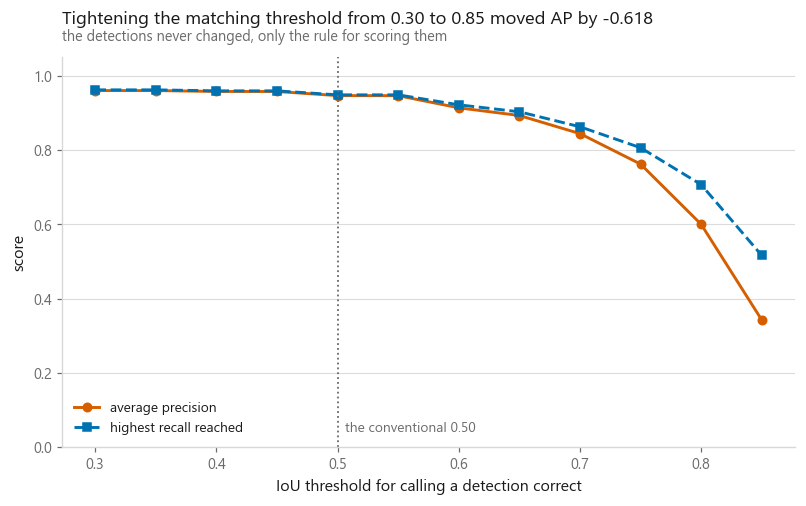

In [15]:
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.plot(by_iou["IoU threshold"], by_iou["AP"], color=style.HIGHLIGHT,
        marker=style.MARKERS[0], label="average precision")
ax.plot(by_iou["IoU threshold"], by_iou["best recall reached"], color=style.PALETTE[0],
        ls=style.DASHES[1], marker=style.MARKERS[1], label="highest recall reached")
ax.axvline(0.5, color=style.MUTED, ls=":", lw=1.2)
ax.annotate("the conventional 0.50", xy=(0.5, 0.04), xytext=(5, 0),
            textcoords="offset points", fontsize=9, color=style.MUTED)

ax.set_xlabel("IoU threshold for calling a detection correct")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower left", fontsize=9)
style.title(
    ax,
    f"Tightening the matching threshold from {by_iou['IoU threshold'].iloc[0]:.2f} to "
    f"{by_iou['IoU threshold'].iloc[-1]:.2f} moved AP by "
    f"{by_iou['AP'].iloc[-1] - by_iou['AP'].iloc[0]:+.3f}",
    "the detections never changed, only the rule for scoring them")
style.save(fig, FIG / "fig-04-ap-against-iou-threshold.png")

This is the reason a detection number is meaningless without its threshold. The
boxes did not move between any two points on that line. Only the rule for calling
one correct did. A model reported at one matching threshold and a model reported
at another are not comparable, and the gap between the ends of that line is how
much room there is to flatter yourself.

### AP against the suppression threshold

In [16]:
NMS_THRESHOLDS = np.round(np.arange(0.10, 0.96, 0.05), 2)

# How much the real objects overlap each other, which is what decides whether a
# permissive threshold has anything to wrongly keep. Every pair of ground-truth
# boxes within an image, scored with the same IoU used for suppression.
truth_pair_iou = np.concatenate(
    [box_iou(b, b)[np.triu_indices(len(b), k=1)] for b in boxes_test if len(b) > 1])

rows = []
for threshold in NMS_THRESHOLDS:
    kept = suppress(raw, float(threshold))
    p, r, _ = precision_recall(kept, boxes_test, 0.5)
    rows.append({"NMS threshold": float(threshold),
                 "AP at IoU 0.50": average_precision(p, r),
                 "boxes kept per image": float(np.mean([len(b) for b, _ in kept])),
                 "best recall reached": float(r.max()) if len(r) else 0.0,
                 "true pairs this overlapping": int((truth_pair_iou > threshold).sum())})

by_nms = pd.DataFrame(rows)
print(by_nms.to_string(index=False, float_format="{:.4f}".format))

best_nms = float(by_nms.loc[by_nms["AP at IoU 0.50"].idxmax(), "NMS threshold"])
print(f"\nbest AP at NMS threshold {best_nms:.2f}: "
      f"{by_nms['AP at IoU 0.50'].max():.4f}")
print(f"AP at the conventional 0.50: "
      f"{float(by_nms.loc[np.isclose(by_nms['NMS threshold'], 0.50), 'AP at IoU 0.50'].iloc[0]):.4f}")
print(f"range of AP across the sweep: "
      f"{by_nms['AP at IoU 0.50'].max() - by_nms['AP at IoU 0.50'].min():.4f}")

# Did the high end fail the way the textbook says it should?
top_ap = float(by_nms["AP at IoU 0.50"].iloc[-1])
peak_ap = float(by_nms["AP at IoU 0.50"].max())
print(f"AP at the most permissive threshold {NMS_THRESHOLDS[-1]:.2f}: {top_ap:.4f}, "
      f"which is {top_ap - peak_ap:+.4f} against the peak")
print(f"pairs of real objects overlapping by more than {NMS_THRESHOLDS[-1]:.2f}: "
      f"{int((truth_pair_iou > NMS_THRESHOLDS[-1]).sum())} of "
      f"{len(truth_pair_iou)}, largest overlap between two real objects "
      f"{truth_pair_iou.max():.4f}")

 NMS threshold  AP at IoU 0.50  boxes kept per image  best recall reached  true pairs this overlapping
        0.1000          0.8682                2.2000               0.8683                           54
        0.1500          0.8870                2.2400               0.8871                           42
        0.2000          0.9058                2.2800               0.9059                           31
        0.2500          0.9187                2.3933               0.9194                           23
        0.3000          0.9291                2.5067               0.9301                           15
        0.3500          0.9422                2.6400               0.9435                           10
        0.4000          0.9448                2.7133               0.9462                            8
        0.4500          0.9446                2.8200               0.9462                            5
        0.5000          0.9469                2.9133               0.9489

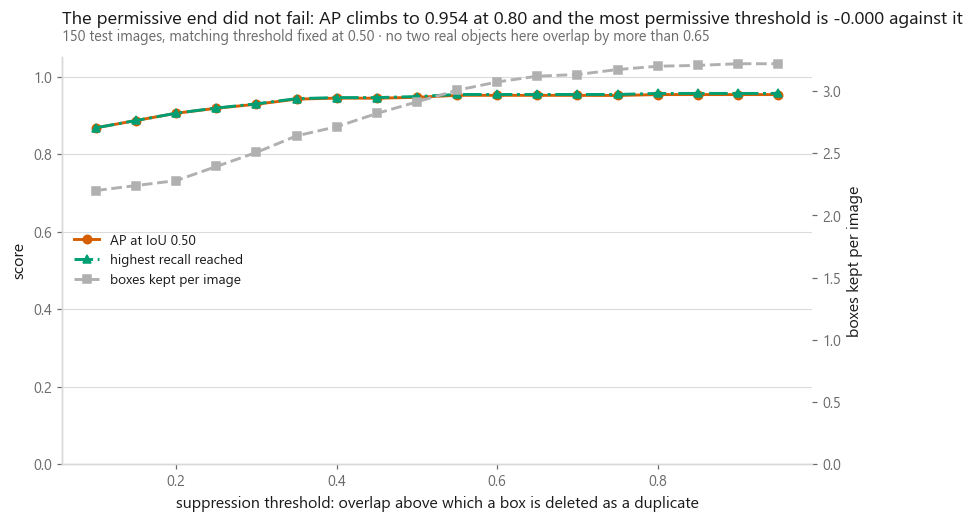

In [17]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.plot(by_nms["NMS threshold"], by_nms["AP at IoU 0.50"], color=style.HIGHLIGHT,
        marker=style.MARKERS[0], label="AP at IoU 0.50")
ax.plot(by_nms["NMS threshold"], by_nms["best recall reached"], color=style.PALETTE[2],
        ls=style.DASHES[2], marker=style.MARKERS[2], label="highest recall reached")
ax.set_xlabel("suppression threshold: overlap above which a box is deleted as a duplicate")
ax.set_ylabel("score")
ax.set_ylim(0, 1.05)

twin = ax.twinx()
twin.plot(by_nms["NMS threshold"], by_nms["boxes kept per image"],
          color=style.NEUTRAL, ls=style.DASHES[1], marker=style.MARKERS[1],
          label="boxes kept per image")
twin.set_ylabel("boxes kept per image")
twin.set_ylim(0, None)
twin.grid(False)

handles = ax.get_legend_handles_labels()[0] + twin.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + twin.get_legend_handles_labels()[1]
ax.legend(handles, labels, loc="center left", fontsize=9)

nms_verdict = ("The permissive end did not fail" if peak_ap - top_ap < 0.01
               else "Both ends of the sweep cost AP")
style.title(
    ax,
    f"{nms_verdict}: AP climbs to {peak_ap:.3f} at {best_nms:.2f} and the most "
    f"permissive threshold is {top_ap - peak_ap:+.3f} against it",
    f"{len(x_test)} test images, matching threshold fixed at 0.50 · no two real "
    f"objects here overlap by more than {truth_pair_iou.max():.2f}")
style.save(fig, FIG / "fig-05-ap-against-nms-threshold.png")

Only one end of that sweep is a failure. AP climbs, then flattens, and the most
permissive threshold in the sweep ties the best one. The textbook story has both
ends failing, and this task refuses to produce the second half of it.

The low end behaves as advertised. Suppressing at a small overlap deletes boxes
sitting on genuinely different objects, the highest recall reached falls with it,
and there is less left to be precise about. The table says how many pairs of real
objects overlap by more than each threshold, and at the bottom of the sweep that
count is large enough to do real damage.

The high end is supposed to fail by keeping duplicates. Precision is computed over
every detection in rank order, so surviving duplicates arrive as false positives
and drag the curve down. Two things stop that happening here. The detector emits
only a few candidate boxes per image above the score floor, barely more than the
number of real objects, so there is hardly a duplicate to keep in the first place:
compare the boxes-kept column at the top of the sweep with the count printed back
in section 4. And the objects are few and rarely on top of each other. The printed
largest overlap between two real objects is below the top of the sweep, so past
that point the suppression threshold has nothing left to decide and the curve goes
flat rather than falling.

So the peak is a property of how crowded your objects are, and this task is not
crowded. A scene with objects genuinely stacked on each other, a street of
pedestrians or a shelf of products, is where a permissive threshold starts keeping
duplicates faster than it rescues true detections, and that is the regime where
the high end bites. Synthetic discs on a mostly empty canvas cannot show it, and
the honest thing to say is that this sweep measured one failure mode and only
assumed the other.

That is the reason to tune this threshold on data that looks like yours rather
than copying a number. The shape of this curve is a fact about the test set as
much as about the detector.

### Accuracy against average precision, on the same model

In [18]:
@torch.no_grad()
def slot_accuracy(model, images, objectness, threshold=0.5, batch=32):
    """Fraction of grid slots where the objectness call was right."""
    model.eval()
    correct = total = 0
    for start in range(0, len(images), batch):
        prediction = model(images[start:start + batch].to(device))
        fired = torch.sigmoid(prediction[..., 0]).cpu() > threshold
        target = objectness[start:start + batch] > 0.5
        correct += int((fired == target).sum())
        total += target.numel()
    model.train()
    return correct / total


obj_test, _, pos_test, _ = encode_targets(boxes_test)
model_slot_accuracy = slot_accuracy(detector, x_test, obj_test)
silent_accuracy = float((obj_test < 0.5).float().mean())

print(f"trained detector : slot accuracy {model_slot_accuracy:.4f}, "
      f"AP at IoU 0.50 {ap50:.4f}")
print(f"a detector that never fires: slot accuracy {silent_accuracy:.4f}, AP 0.0000")
print(f"\nThe silent model is behind on slot accuracy by "
      f"{model_slot_accuracy - silent_accuracy:+.4f} and behind on AP by "
      f"{-ap50:+.4f}.")
print("Accuracy over the grid is dominated by empty slots, and it says nothing "
      "about where the boxes landed, how they were ranked, or whether two of them "
      "claimed the same object.")

trained detector : slot accuracy 0.9978, AP at IoU 0.50 0.9469
a detector that never fires: slot accuracy 0.9809, AP 0.0000

The silent model is behind on slot accuracy by +0.0169 and behind on AP by -0.9469.
Accuracy over the grid is dominated by empty slots, and it says nothing about where the boxes landed, how they were ranked, or whether two of them claimed the same object.


In [19]:
print(f"whole notebook: {(time.perf_counter() - NOTEBOOK_STARTED) / 60:.1f} minutes on {device}")

whole notebook: 0.2 minutes on cuda


### What this detector is not

One class, one feature map, two anchor sizes, synthetic discs on a plain
background, one seed. A real detector predicts a class distribution alongside
objectness, works from several feature maps so that small and large objects are
handled at appropriate resolutions, uses a matching rule based on anchor IoU
rather than the nearest anchor size, and trains with hard negative mining or a
focal loss instead of the single `pos_weight` above.

None of that changes the evaluation machinery, which is the reason this notebook
spends most of its length there. Swap the model and every function in section 3
still applies unaltered.

## Cheat sheet

| | |
|---|---|
| **Boxes** | `(x1, y1, x2, y2)`, and check which convention a library uses before trusting a number |
| **IoU** | Intersection area over union area. The `max(0, ...)` in the overlap is what handles disjoint boxes |
| **Anchors** | Reference boxes at fixed positions and sizes. The network predicts corrections, not coordinates |
| **Parameterisation** | `sigmoid` on the centre offset keeps it inside its cell, `exp` on the size keeps it positive and centred on the anchor |
| **Class imbalance** | Nearly every slot is background. Weight the positive term, or the model learns to stay silent |
| **NMS** | Greedy: keep the best, delete everything overlapping it beyond a threshold, repeat. It cannot keep two heavily overlapping true objects |
| **AP** | Area under the interpolated precision-recall curve, with detections pooled and ranked by confidence |
| **Always state** | The matching IoU threshold. AP at 0.50 and AP averaged from 0.50 up are different numbers for the same model |
| **The suppression sweep** | Its shape is a fact about your data. On this uncrowded task AP climbed and then flattened, and the permissive end never failed, because there was nothing left for it to wrongly keep |
| **Watch out** | A second detection on an already-claimed object is a false positive, not a duplicate to be ignored |

## What to remember

1. Detection returns a variable-length ranked list, which is why accuracy does
   not apply and average precision does.
2. The grid-slot accuracy printed in section 5 is high for a model that never
   fires. That number is the background rate wearing a disguise.
3. IoU, NMS and AP are a few lines each. Section 3 checks all three against cases
   worked out by hand.
4. AP depends on the matching threshold, and the detections do not change when
   you move it. Compare two models only at the same threshold.
5. AP also depends on the suppression threshold, and only the low end lost here.
   Suppressing at a small overlap deleted real objects and cost recall, as
   expected. The permissive end was supposed to flood the ranking with duplicates
   and did not, because the detector emitted barely more candidate boxes than
   there were objects and no two real objects overlapped enough for the choice to
   matter. Tune this on data shaped like yours; a crowded scene is where the high
   end bites and this one cannot show it.
6. A single-shot grid cannot represent two objects that want the same cell and
   anchor. Section 4 counts how many the training set lost that way.
7. Anchors exist so the network predicts a correction to a plausible box instead
   of learning absolute coordinates from scratch.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-01 Text preprocessing, bag of words, and TF-IDF](../../09-sequences-and-language/01-text-preprocessing/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#ObjectDetection` `#ComputerVision` `#PyTorch` `#AveragePrecision`
`#NonMaximumSuppression` `#IoU` `#MachineLearning` `#MLTutorial` `#AI`